# Análise de Receita e Segmentação ABC de Clientes

## Contexto
Este projeto tem como objetivo analisar a concentração de receita e classificar clientes utilizando a metodologia ABC (Curva de Pareto), com foco em priorização estratégica comercial.

## Perguntas de Negócio
- Existe concentração de receita em poucos clientes?
- Quem são os clientes mais relevantes?
- Como segmentar a base para tomada de decisão?

In [31]:
import pandas as pd 
import matplotlib.pyplot as plt


In [32]:
df = pd.read_csv("sales.csv", encoding="latin1")
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [33]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [34]:
receita_total = df["SALES"].sum()
total_clientes = df["CUSTOMERNAME"].nunique()

print(f"Receita Total: {receita_total:.2f}")
print(f"Total de Clientes: {total_clientes}")


Receita Total: 10032628.85
Total de Clientes: 92


In [35]:
receita_cliente = (df.groupby("CUSTOMERNAME")["SALES"].sum().reset_index())

receita_cliente = receita_cliente.sort_values(by="SALES", ascending=False)

In [36]:
receita_cliente["perc_receita"] = receita_cliente["SALES"] / receita_total
receita_cliente["perc_acumulado"] = receita_cliente["perc_receita"].cumsum()

In [37]:
# Seguimentação ABC

def classificar(x):
    if x <= 0.5:
        return "A - Alto Valor"
    elif x <= 0.8:
        return "B - Médio Valor"
    else:
        return "C - Baixo Valor"
    
receita_cliente["segmento"] = receita_cliente["perc_acumulado"].apply(classificar)

receita_cliente["segmento"].value_counts()

segmento
C - Baixo Valor    36
B - Médio Valor    31
A - Alto Valor     25
Name: count, dtype: int64

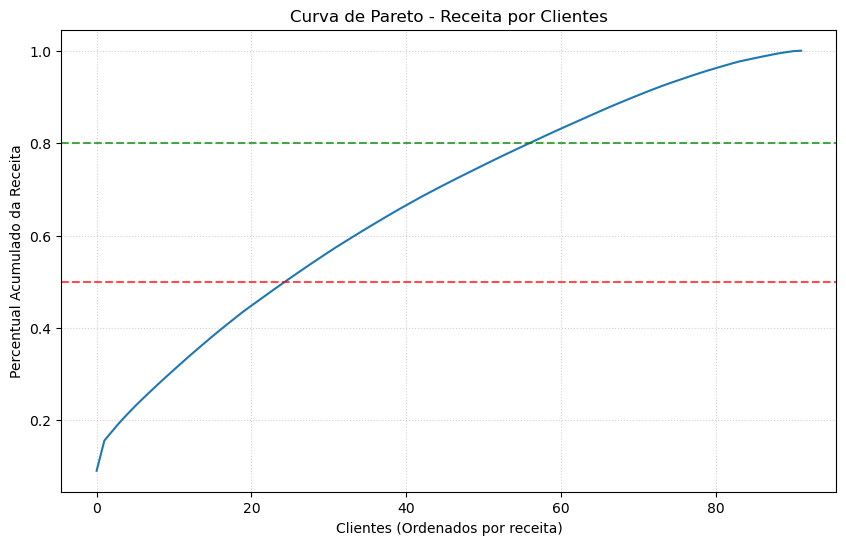

In [38]:
# Curva de Pareto

plt.figure(figsize=(10,6))

plt.plot(receita_cliente["perc_acumulado"].reset_index(drop=True))
plt.axhline(0.5, linestyle= "--", color= "red", alpha= 0.7, label= 'Limite 50% (Classe A)')
plt.axhline(0.8, linestyle= "--", color= "green", alpha= 0.7, label= 'Limite 80% (Classe B)')
plt.title("Curva de Pareto - Receita por Clientes")
plt.xlabel("Clientes (Ordenados por receita)")
plt.ylabel("Percentual Acumulado da Receita")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

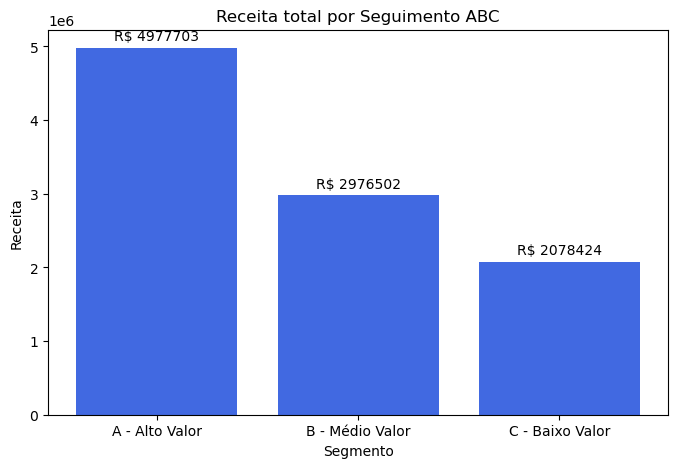

In [39]:
# Receita por segmento

resumo_segmento = (receita_cliente.groupby("segmento")["SALES"].sum().reset_index())

plt.figure(figsize=(8,5))
barras = plt.bar(resumo_segmento["segmento"], resumo_segmento["SALES"], color='royalblue')

plt.bar_label(barras, padding=3, fmt='R$ %.0f')
plt.title("Receita total por Seguimento ABC")
plt.xlabel("Segmento")
plt.ylabel("Receita")
plt.show()


## Conclusões

- Observa-se forte concentração de receita em um grupo reduzido de clientes.
- Clientes classificados como A representam aproximadamente 50% da receita total.
- A empresa apresenta dependência significativa de poucos clientes estratégicos.
- Recomenda-se priorizar ações de retenção e relacionamento para clientes A.
- Clientes C representam oportunidade para campanhas de expansão de ticket médio.